In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error


In [17]:
## 1. Data Ingestion

In [18]:
df = pd.read_excel(r'C:\AQI_PredicationModel\data\AirQualityUCI.xlsx')

df.sample(frac=1)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
7022,2004-12-28,08:00:00,-200.0,1358.25,-200,15.291846,1157.75,-200.0,529.00,-200.0,1536.50,1325.50,9.275000,77.000000,0.901844
6758,2004-12-17,08:00:00,4.1,-200.00,-200,-200.000000,-200.00,854.0,-200.00,137.0,-200.00,-200.00,-200.000000,-200.000000,-200.000000
42,2004-03-12,12:00:00,2.1,1206.25,114,10.224662,986.00,143.0,1034.50,113.0,1537.00,959.00,15.025000,36.500000,0.619532
4927,2004-10-02,01:00:00,-200.0,1133.50,-200,8.350804,913.50,-200.0,699.25,-200.0,1512.00,1097.00,20.575001,63.425000,1.519047
3487,2004-08-03,01:00:00,-200.0,1007.75,-200,6.573944,838.00,28.0,774.25,50.0,1639.75,733.00,26.225000,52.325000,1.756127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5757,2004-11-05,15:00:00,4.3,1492.25,-200,26.352867,1463.00,527.0,460.00,138.0,1934.50,1632.00,24.175000,43.975000,1.307762
8514,2005-02-28,12:00:00,0.8,805.25,-200,2.002013,584.25,163.9,1137.00,119.2,725.50,384.50,3.700000,38.775001,0.312300
5494,2004-10-25,16:00:00,5.0,1584.00,-200,32.006211,1597.25,666.0,392.00,125.0,2176.25,1844.50,21.575000,62.025001,1.578420
3037,2004-07-15,07:00:00,2.3,1132.00,-200,15.564889,1166.25,168.0,652.25,108.0,1827.25,1228.75,21.325000,48.350000,1.211945


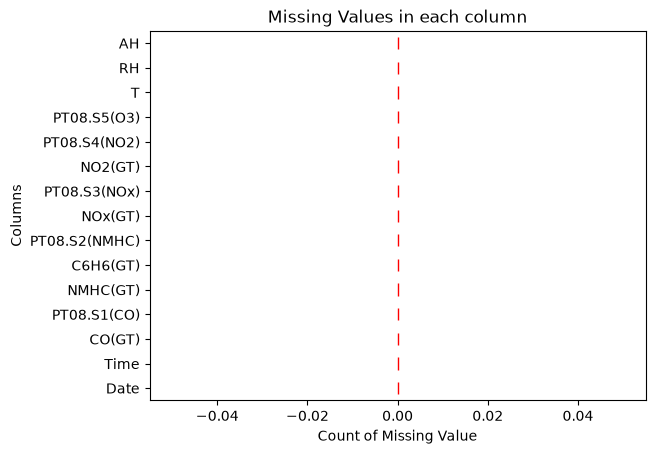

In [19]:
# checking Missing value info using graphical method

df.isnull().sum().plot(kind = 'barh', color = 'gray',edgecolor = 'red')
plt.title("Missing Values in each column")
plt.xlabel('Count of Missing Value')
plt.ylabel('Columns')
plt.show()

In [ ]:
# Checking duplicat values in data set
df.duplicated().sum()
# Droping duplicated values from Dataset

df.drop_duplicates(inplace = True)

df.shape

np.int64(0)

In [31]:
# Drop Unwanted Column 
df = df.drop(columns=['Date','Time'])
df.columns

Index(['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
       'T', 'RH', 'AH'],
      dtype='object')

In [32]:
numerical_data = df.select_dtypes(exclude='object')
categorical_data = df.select_dtypes(include='object')

from collections import OrderedDict

stats = []

for i in numerical_data.columns:

    feature_stats = OrderedDict({
        'Feature': i,
        'Count': df[i].count(),
        'Mean': df[i].mean(),
        'Median': df[i].median(),
        'Std': df[i].std(),
        'Min': df[i].min(),
        'Max': df[i].max(),
        'Q1': df[i].quantile(0.25),
        'Q3': df[i].quantile(0.75),
        'IQR': df[i].quantile(0.75) - df[i].quantile(0.25),
        'Lower Whisker': df[i].quantile(0.25) -1.5 * (df[i].quantile(0.75) - df[i].quantile(0.25)),
        'Upper Whisker': df[i].quantile(0.75) + 1.5 * (df[i].quantile(0.75) - df[i].quantile(0.25)),
    })

    stats.append(feature_stats)

report = pd.DataFrame(stats)

report

,Feature,Count,Mean,Median,Std,Min,Max,Q1,Q3,IQR,Lower Whisker,Upper Whisker
0,CO(GT),9357,-34.207524,1.500000,77.657170,-200.0,11.900000,0.600000,2.600000,2.000000,-2.400000,5.600000
1,PT08.S1(CO),9357,1048.869652,1052.500000,329.817015,-200.0,2039.750000,921.000000,1221.250000,300.250000,470.625000,1671.625000
2,NMHC(GT),9357,-159.090093,-200.000000,139.789093,-200.0,1189.000000,-200.000000,-200.000000,0.000000,-200.000000,-200.000000
3,C6H6(GT),9357,1.865576,7.886653,41.380154,-200.0,63.741476,4.004958,13.636091,9.631133,-10.441742,28.082791
4,PT08.S2(NMHC),9357,894.475963,894.500000,342.315902,-200.0,2214.000000,711.000000,1104.750000,393.750000,120.375000,1695.375000
5,NOx(GT),9357,168.604200,141.000000,257.424561,-200.0,1479.000000,50.000000,284.200000,234.200000,-301.300000,635.500000
6,PT08.S3(NOx),9357,794.872333,794.250000,321.977031,-200.0,2682.750000,637.000000,960.250000,323.250000,152.125000,1445.125000
7,NO2(GT),9357,58.135898,96.000000,126.931428,-200.0,339.700000,53.000000,133.000000,80.000000,-67.000000,253.000000
8,PT08.S4(NO2),9357,1391.363266,1445.500000,467.192382,-200.0,2775.000000,1184.750000,1662.000000,477.250000,468.875000,2377.875000
9,PT08.S5(O3),9357,974.951534,942.000000,456.922728,-200.0,2522.750000,699.750000,1255.250000,555.500000,-133.500000,2088.500000


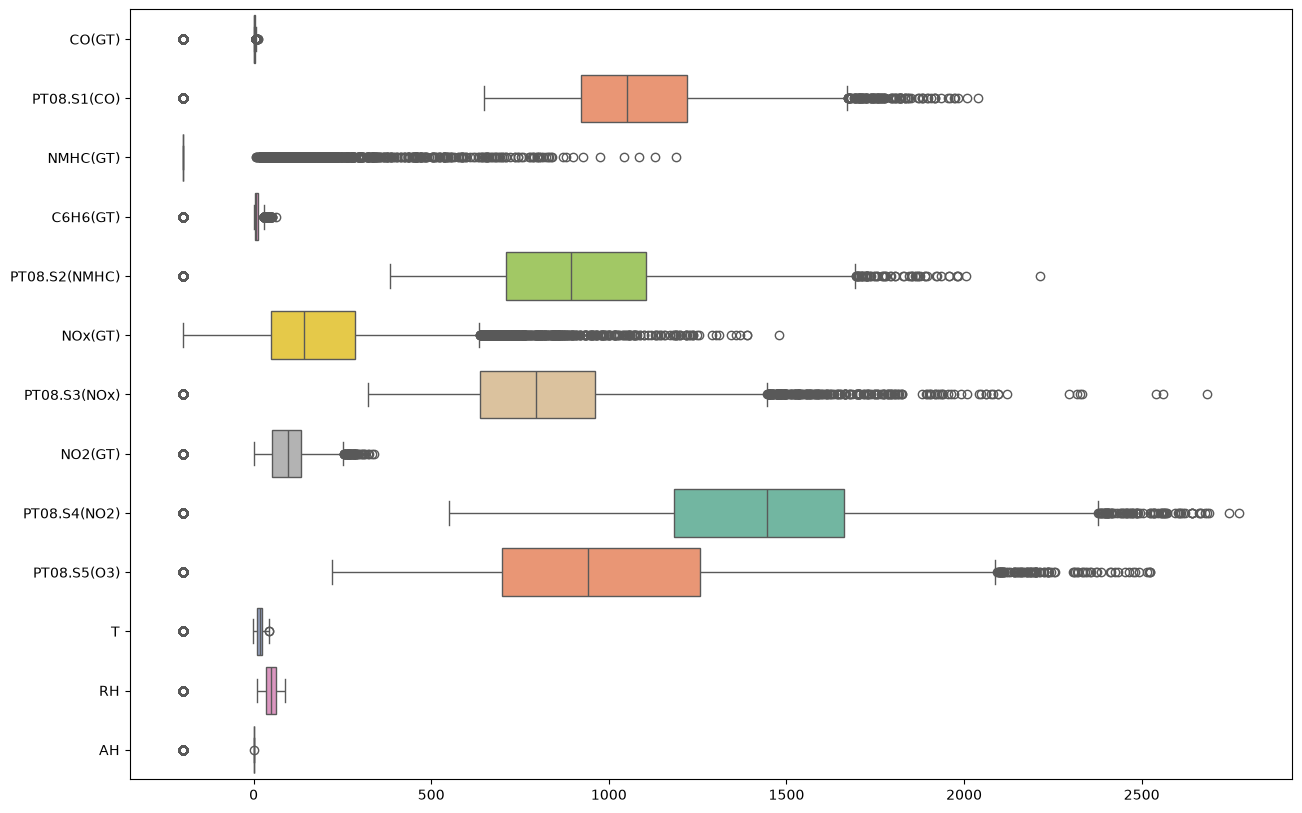

In [36]:
# Checking Outliers using Boxplot
plt.figure(figsize = (15,10))
sns.boxplot(data = df,orient = 'h', palette = 'Set2')
plt.show()

In [38]:
X = df.drop(columns=['AH'])
y = df['AH']

In [49]:

categorical_data = X.select_dtypes(include='object').columns
numerical_data = X.select_dtypes(exclude='object').columns

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=0.3,
                                                        random_state=1)

In [43]:
X_train.shape, X_test.shape, y_train.shape,y_test.shape

((6549, 12), (2808, 12), (6549,), (2808,))

In [45]:
numerical_pipeline = Pipeline(steps=[('Imputer', SimpleImputer(strategy='median')),
                                     ('Scaler', RobustScaler())])

categorical_pipeline = Pipeline(steps=[('Imputer',
                                        SimpleImputer(strategy='most_frequent')),
                                       ('Encoder', OneHotEncoder(drop='first',
                                        handle_unknown='ignore',sparse_output=False))])


In [50]:

transformer = ColumnTransformer(transformers=[
            ('num', numerical_pipeline, numerical_data),
            ('cat', categorical_pipeline, categorical_data)])
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

def r2_score_model(X_train, X_test, y_train, y_test):
    
    model = RandomForestRegressor(n_estimators=100)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2score = r2_score(y_test, y_pred)
    print("The R2 score is:", r2score)
    
    return y_pred, r2score
y_pred, r2score = r2_score_model(X_train,X_test,y_train,y_test)

The R2 score is: 0.999999804730572


In [63]:
def k_fold_model(X_train, y_train):

    model = RandomForestRegressor(n_estimators=100)
    kf = KFold(n_splits=100,shuffle=True,)
    cv_scores = cross_val_score(model,X_train,y_train,cv=kf,scoring="r2")
    cv_mean = cv_scores.mean()
    cv_mean = cv_scores.mean()
    print("Cross-validation scores:", cv_scores)
    print("Mean cross-validation R2 score:", cv_mean)
    return cv_scores, cv_mean

cv_scores, cv_mean = k_fold_model(X_train,y_train)

Cross-validation scores: [0.99999942 0.99999987 0.99999998 0.99999933 0.99999973 0.99999997
 0.99999991 0.99999983 0.99999991 0.99999967 0.99999993 0.99999979
 0.99999992 0.99999998 0.99999981 0.99999984 0.99999973 0.99933121
 0.9999999  0.99999934 0.99999983 0.99999978 0.99999943 0.99999985
 0.99999994 0.99999925 0.99999985 0.99999985 0.99999957 0.99999988
 0.99922676 0.99999991 0.99999996 0.99999992 0.99999947 0.9999999
 0.99999976 0.99999987 0.99999995 0.99999994 0.99999971 0.9981986
 0.99999917 0.99999993 0.99999977 0.99999986 0.99999991 0.99999987
 0.99999986 0.99999988 0.99741005 0.99999996 0.99999982 0.99999998
 0.9999998  0.99999984 0.99999989 0.99999994 0.99999991 0.99999979
 0.99999992 0.9999999  0.99999997 0.99999994 0.99999994 0.99999994
 0.99999968 0.99999948 0.99999994 0.99999994 0.99999989 0.99999985
 0.99999993 0.99999976 0.99999995 0.99999996 0.99923342 0.99999996
 0.99999996 0.99999972 0.99999996 0.99999954 0.99999974 0.99999989
 0.99854481 0.9999999  0.99999992 0.999